# 시계열 ACF 연습 (PyTorch)

`statsmodels` 결과와 PyTorch 직접 구현을 비교합니다.
아래에서는 **한 줄씩** 실행하며 표본 ACF가 어떻게 계산되는지 확인한 뒤, 마지막에 함수로 묶습니다.

In [27]:
from statsmodels.tsa.stattools import acf as sm_acf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


## 1. 데이터

In [28]:
df = pd.read_csv('../data/widget_sales.csv')
series = df['widget_sales'].to_numpy()
x = torch.tensor(series, dtype=torch.float32)

MAX_LAG = 20  # 이후 ACF에서 사용할 최대 lag

x.shape, x[:5]


(torch.Size([500]), tensor([50.4967, 50.8055, 51.4778, 53.5422, 54.8731]))

## 2. 시계열 시각화

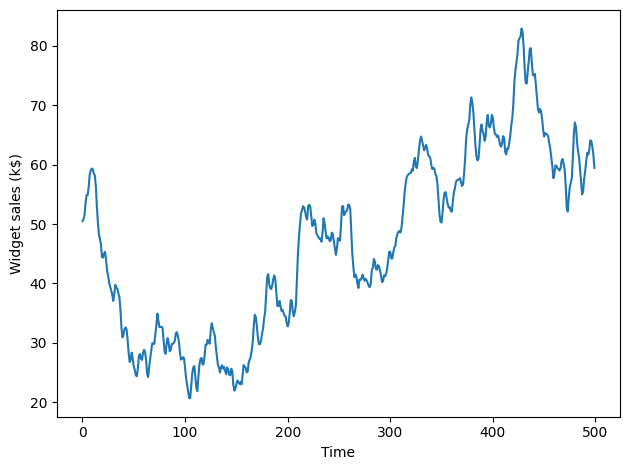

In [29]:
plt.figure()
plt.plot(series)
plt.xlabel('Time')
plt.ylabel('Widget sales (k$)')
plt.tight_layout()


## 3. ACF가 되는 이유 — 단계별로 확인

표본 자기상관:

$$\hat{\rho}(k) = \frac{\sum_{t=k}^{n-1}(x_t - \bar{x})(x_{t-k} - \bar{x})}{\sum_{t=1}^{n}(x_t - \bar{x})^2}$$

- **분자**: lag $k$에서 두 시점의 **편차 곱**을 더함
- **분모**: 편차 제곱합 → $k=0$이면 1이 됨


In [30]:
# ① 시계열을 1차원으로 맞춤
x = x.float().flatten()
n = x.numel()
n


500

In [31]:
# ② 평균을 빼면 공분산 형태의 분자·분모가 정리됨 (상수 시계열은 분모=0 주의)
xc = x - x.mean()
xc[:5], xc.mean()  # mean ≈ 0


(tensor([3.5269, 3.8356, 4.5079, 6.5724, 7.9032]), tensor(-5.2643e-06))

In [32]:
# ③ 분모 = sum (x_t - x_bar)^2  →  rho(0) = 1 이 되도록 정규화
denom = (xc * xc).sum()
denom.item()


118073.6171875

In [33]:
# ④ lag k, 시점 t 격자 (브로드캐스팅용)
#     행 = k (0..MAX_LAG), 열 = t (0..n-1)
k = torch.arange(MAX_LAG + 1).unsqueeze(1)   # (L, 1)
t = torch.arange(n).unsqueeze(0)             # (1, n)
k.shape, t.shape


(torch.Size([21, 1]), torch.Size([1, 500]))

In [34]:
# ⑤ lag k에서는 t >= k 인 시점만 유효 (그보다 작은 t는 짝이 없음)
valid = t >= k
valid.shape, valid[0, :8], valid[1, :8]  # k=0: 전부 True, k=1: 첫 칸 False


(torch.Size([21, 500]),
 tensor([True, True, True, True, True, True, True, True]),
 tensor([False,  True,  True,  True,  True,  True,  True,  True]))

In [35]:
# ⑥ 각 (k,t)에서 xc[t] * xc[t-k]  (유효하지 않은 칸은 나중에 0으로)
#     t-k < 0 은 clamp로 인덱스만 막고, valid 마스크로 실제 합에서는 제외
prod = xc[t] * xc[(t - k).clamp(min=0)]
prod.shape, prod[0, :5], prod[1, :5]


(torch.Size([21, 500]),
 tensor([12.4387, 14.7120, 20.3211, 43.1960, 62.4613]),
 tensor([12.4387, 13.5277, 17.2906, 29.6275, 51.9430]))

In [36]:
# ⑦ lag별로 열 방향 sum → 자기공분산(분자), k=0..MAX_LAG
acov = (prod * valid).sum(dim=1)
acov.shape, acov[:5]


(torch.Size([21]),
 tensor([118073.6172, 117537.9219, 116422.2969, 115159.8203, 113912.0391]))

In [37]:
# ⑧ 분모로 나누면 표본 ACF
acf_manual = acov / denom
acf_manual[:5], acf_manual[0].item()  # lag 0 은 항상 1


(tensor([1.0000, 0.9955, 0.9860, 0.9753, 0.9648]), 1.0)

In [38]:
# ⑨ lag=1만 손으로 계산해 보기 (위 결과와 같은지)
k1 = 1
manual_k1 = (xc[1:] * xc[:-1]).sum() / denom
manual_k1.item(), acf_manual[1].item()


(0.9954630136489868, 0.9954630136489868)

## 4. 완성 코드 (`acf` 함수)

위 단계를 그대로 묶은 형태입니다.

In [39]:
def acf(x: torch.Tensor, max_lag: int) -> torch.Tensor:
    """
    표본 ACF. 텐서 인덱싱·브로드캐스팅만 사용.
    x: (n,) 1차원 시계열 → (max_lag+1,)
    """
    x = x.float().flatten()
    xc = x - x.mean()
    n = xc.numel()
    denom = (xc * xc).sum()

    k = torch.arange(max_lag + 1, device=x.device).unsqueeze(1)
    t = torch.arange(n, device=x.device).unsqueeze(0)
    valid = t >= k

    prod = xc[t] * xc[(t - k).clamp(min=0)]
    acov = (prod * valid).sum(dim=1)

    return acov / denom


## 5. statsmodels 와 비교 (원시 시계열)

In [45]:
acf_pt = acf(x, MAX_LAG)
acf_sm = torch.tensor(sm_acf(series, nlags=MAX_LAG, fft=True), dtype=torch.float32)

print('일치:', torch.allclose(acf_pt, acf_sm, atol=1e-5))
torch.stack([acf_pt, acf_sm], dim=1)  # columns: pytorch, statsmodels


일치: True


tensor([[1.0000, 1.0000],
        [0.9955, 0.9955],
        [0.9860, 0.9860],
        [0.9753, 0.9753],
        [0.9648, 0.9648],
        [0.9545, 0.9545],
        [0.9443, 0.9443],
        [0.9341, 0.9341],
        [0.9242, 0.9242],
        [0.9151, 0.9151],
        [0.9068, 0.9068],
        [0.8987, 0.8987],
        [0.8904, 0.8904],
        [0.8817, 0.8817],
        [0.8727, 0.8727],
        [0.8634, 0.8634],
        [0.8536, 0.8536],
        [0.8434, 0.8434],
        [0.8329, 0.8329],
        [0.8224, 0.8224],
        [0.8127, 0.8127]])

## 6. 차분 시계열

비정상 시계열은 차분 후 ACF 패턴이 달라집니다.

In [41]:
widget_sales_diff = np.diff(series)

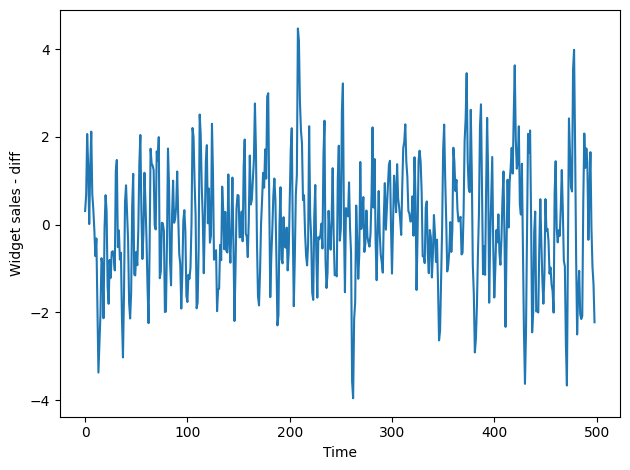

In [42]:
plt.figure()
plt.plot(widget_sales_diff)
plt.xlabel('Time')
plt.ylabel('Widget sales - diff')
plt.tight_layout()


## 7. 차분 시계열 ACF 비교

In [44]:
x_diff = torch.tensor(widget_sales_diff, dtype=torch.float32)

acf_pt_d = acf(x_diff, MAX_LAG)
acf_sm_d = torch.tensor(sm_acf(widget_sales_diff, nlags=MAX_LAG, fft=True), dtype=torch.float32)

print('일치:', torch.allclose(acf_pt_d, acf_sm_d, atol=1e-5))
torch.stack([acf_pt_d, acf_sm_d], dim=1)


일치: True


tensor([[ 1.0000,  1.0000],
        [ 0.6099,  0.6099],
        [ 0.1410,  0.1410],
        [-0.0378, -0.0378],
        [-0.0458, -0.0458],
        [ 0.0070,  0.0070],
        [ 0.0161,  0.0161],
        [-0.0510, -0.0510],
        [-0.1031, -0.1031],
        [-0.0725, -0.0725],
        [-0.0028, -0.0028],
        [ 0.0564,  0.0564],
        [ 0.0513,  0.0513],
        [ 0.0212,  0.0212],
        [ 0.0281,  0.0281],
        [ 0.0439,  0.0439],
        [ 0.0477,  0.0477],
        [ 0.0210,  0.0210],
        [-0.0329, -0.0329],
        [-0.1107, -0.1107],
        [-0.1539, -0.1539]])